# FoodHub Data Analysis


### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on these restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. FoodHub is a food aggregator company that offers access to multiple restaurants through a single smartphone app. Foodhub earns money by collecting a fixed margin of the delivery order from the restaurants.This analysis examines 1,898 orders of customers from 178 restaurants across 14 cuisine types.


### Data Description and Dictionary

The data contains the different data related to a food order. The detailed data dictionary is given below.

| Column | Description |
|--------|-------------|
| order_id | Unique order identifier |
| customer_id | Customer identifier |
| restaurant_name | Restaurant name |
| cuisine_type | Cuisine category |
| cost_of_the_order | Order cost (USD) |
| day_of_the_week | Weekday or Weekend |
| rating | Customer rating (1-5 or Not given) |
| food_preparation_time | Prep time (minutes) |
| delivery_time | Delivery time (minutes) |

### Importing the necessary libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.style as style
%matplotlib inline

### Importing the data

In [2]:
df = pd.read_csv('foodhub_order.csv')

### Performing sanity checks on the data

In [3]:
#viewing the data
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [4]:
#checking the datatypes
df.dtypes

order_id                   int64
customer_id                int64
restaurant_name           object
cuisine_type              object
cost_of_the_order        float64
day_of_the_week           object
rating                    object
food_preparation_time      int64
delivery_time              int64
dtype: object

In [5]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

In [6]:
#checking for missing values
df.isnull().sum()

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

In [7]:
#checking for summary numerical statistics
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


In [8]:
#This shows the statistcs the categorical variables.
df.describe(include='object')

,restaurant_name,cuisine_type,day_of_the_week,rating
count,1898,1898,1898,1898
unique,178,14,2,4
top,Shake Shack,American,Weekend,Not given
freq,219,584,1351,736


## Exploratory Data Analysis (EDA)

### Univariate Analysis
### Exploring the variables and providing observations on their distributions.

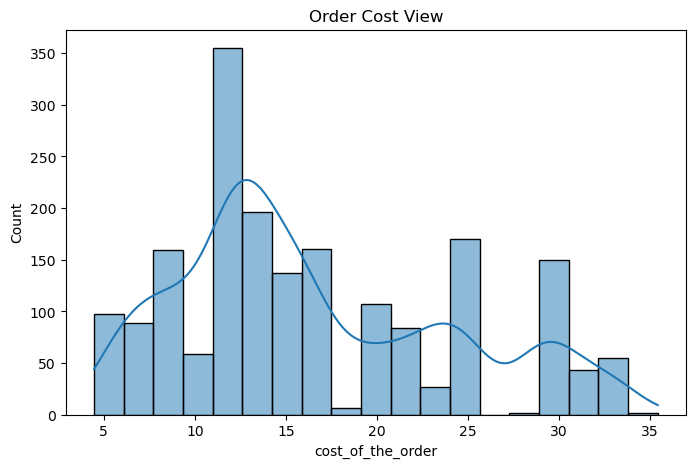

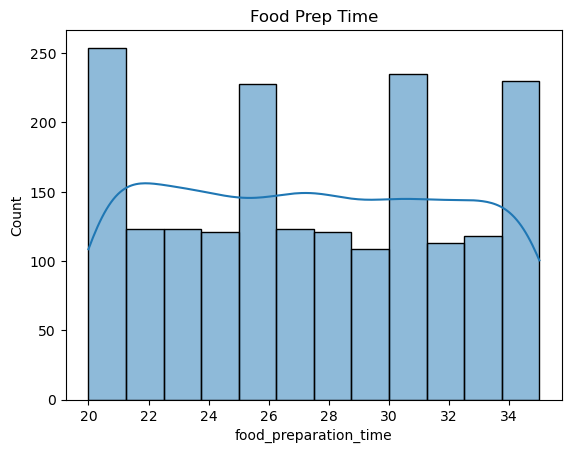

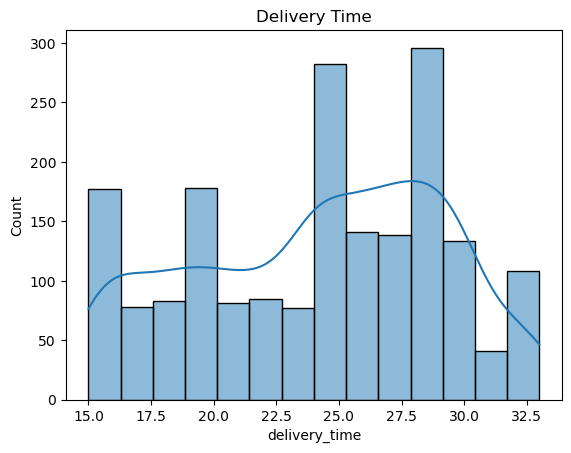

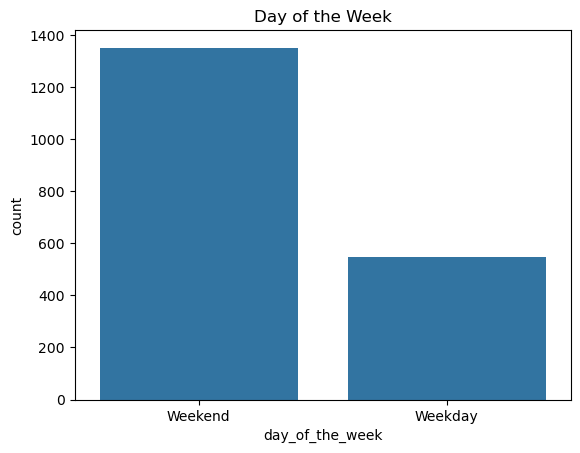

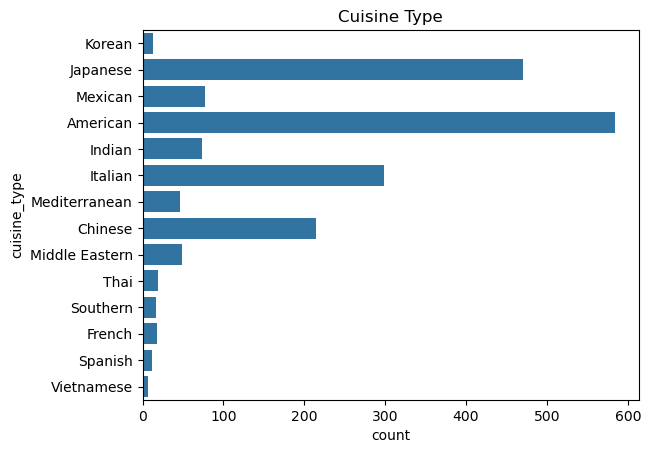

In [9]:
# Plotting  Histograms for numerical variables
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='cost_of_the_order', kde=True)
plt.title('Order Cost View')
plt.show()

sns.histplot(data=df, x='food_preparation_time', kde=True)
plt.title('Food Prep Time')
plt.show()

sns.histplot(data=df, x='delivery_time', kde=True)
plt.title('Delivery Time')
plt.show()

# Using Count plot for categorical variables
sns.countplot(data=df, x='day_of_the_week')
plt.title('Day of the Week')
plt.show()

sns.countplot(data=df, y='cuisine_type')
plt.title('Cuisine Type')
plt.show()

# **Observations**
### From the above, Most Orders cost between 10 to 25 dollars.It is noted that, most restaurant have almost the same food preparation time.Weekends have the highest order.American cuisine type has the highest purchase.

# Orders not rated

In [10]:
# from viewing the data, inside the rating column we can see 'Not given'.Count how many times 'Not given' appears in the rating column
not_rated_count = df['rating'].value_counts().head(1)
print( not_rated_count)

rating
Not given    736
Name: count, dtype: int64


#### 736 orders total do not have a customer rating

# The top 5 restaurants in terms of the number of orders received

In [11]:
top_5 = df['restaurant_name'].value_counts().nlargest(5)
top_5 = top_5.sort_values(ascending=True)
top_5

restaurant_name
Parm                          68
Blue Ribbon Fried Chicken     96
Blue Ribbon Sushi            119
The Meatball Shop            132
Shake Shack                  219
Name: count, dtype: int64

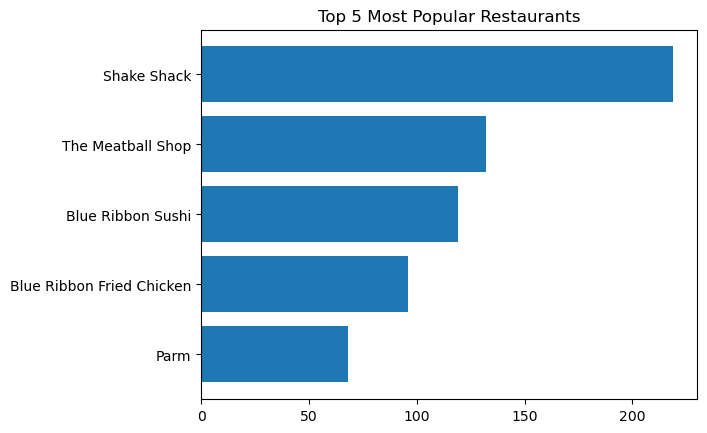

In [12]:
#visualize the top 5
plt.barh(y=top_5.index,
           width = top_5.values)
plt.title('Top 5 Most Popular Restaurants');

### Shake Shack and The Meatball Shop are the leading partners, driving the highest volume and order frequency on the app.

# The most popular cuisine on weekends

In [13]:
popular_cuisine_weekends =df[df['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts().head(1)
popular_cuisine_weekends

cuisine_type
American    415
Name: count, dtype: int64

### American cuisine is the clear favorite for the customers during the weekend, outperforming all other food categories.

# Identifying percentage of the orders that cost more than 20 dollars

In [14]:
# 1. Count orders that cost more than 20 dollars
orders_above_20 = df[df['cost_of_the_order'] > 20].shape[0]

# 2. Get the total number of orders in the dataset
total_orders = df.shape[0]

# 3. Calculate the percentage
percentage_above_20 = (orders_above_20 / total_orders) * 100

# 4. Print the result rounded to 2 decimal places
print('Percentage of orders costing more than 20 dollars:', round(percentage_above_20, 2), '%')

Percentage of orders costing more than 20 dollars: 29.24 %


# The Average order delivery time

In [15]:
#check the mean 
mean_avg_time = df['delivery_time'].mean().round(2)
print('The average Order Delivery time is:',mean_avg_time)

The average Order Delivery time is: 24.16


# The top 3 most frequent customers.

In [16]:
# Count order frequency per customer ID and show the top 3
top_3_customers = df['customer_id'].value_counts().head(3)
print("Top 3 Customers:\n",top_3_customers)

Top 3 Customers:
 customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


### These are the most loyal brand advocates, with the top three customers placing between 9 and 13 orders

## Bivariate/Multivariate Analysis

### Performing a bivariate/multivariate analysis to explore relationships between the important variables in the dataset.


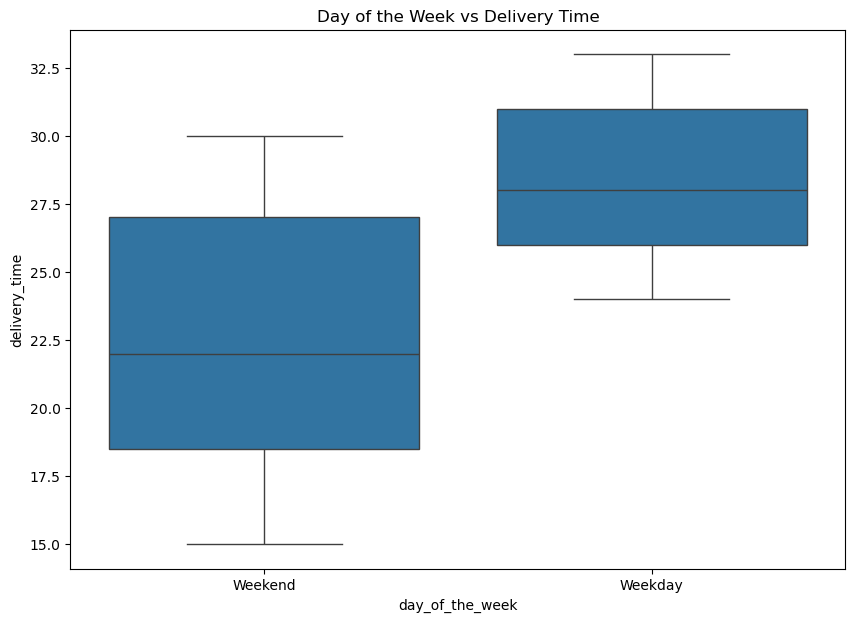

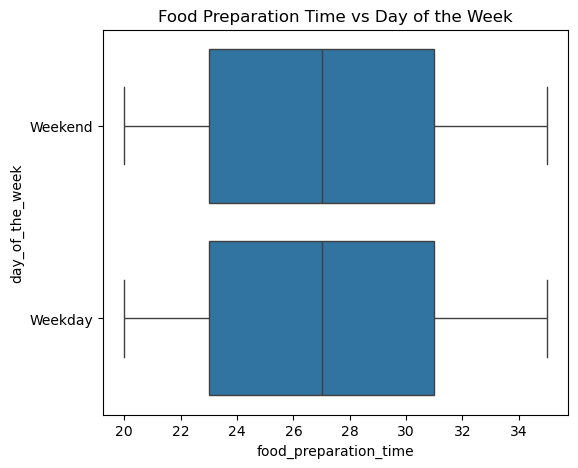

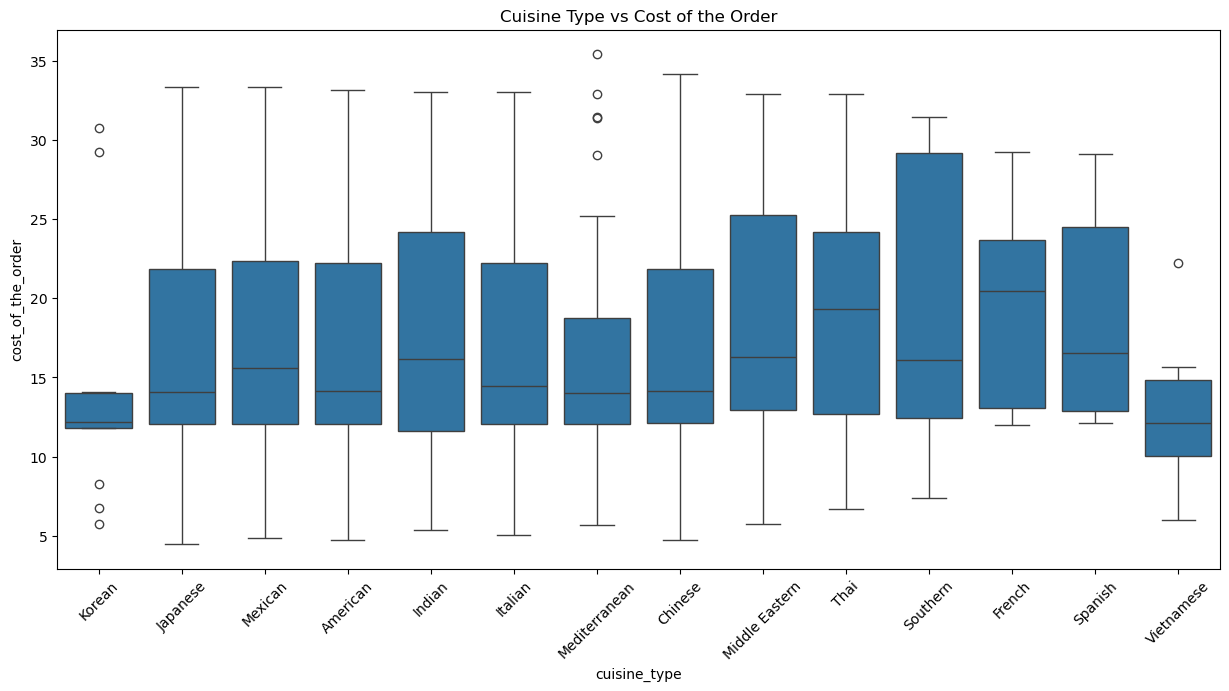

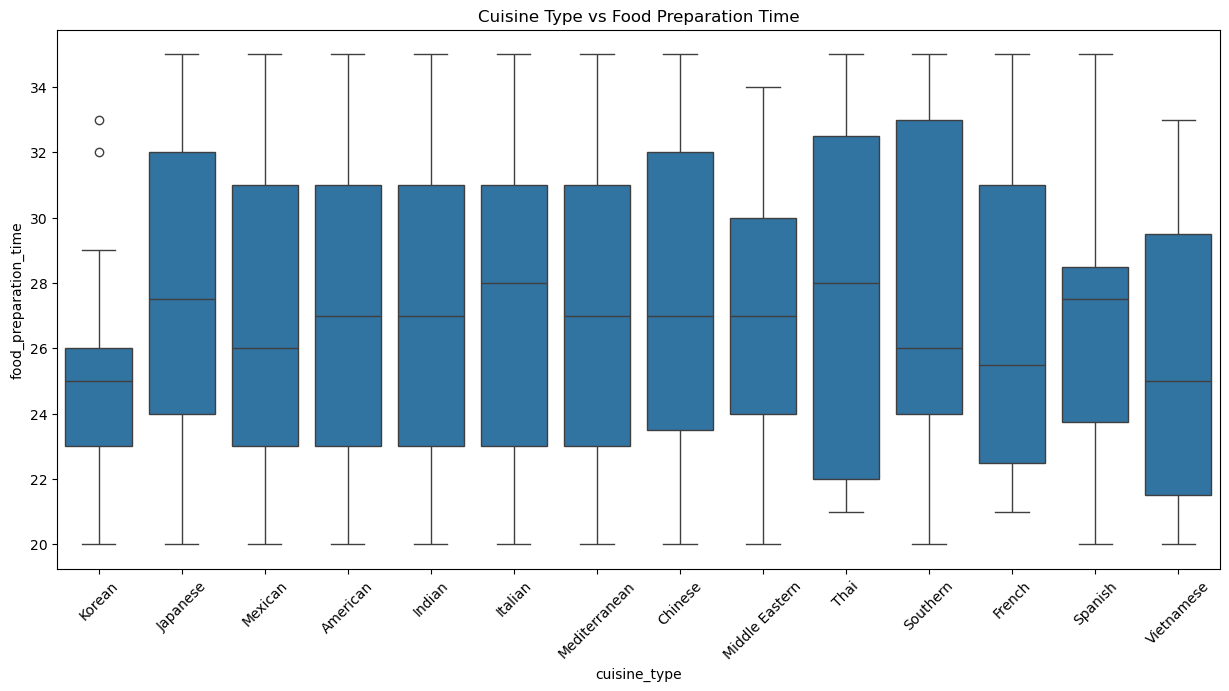

In [17]:
#1. Day of the week vs. Delivery time
plt.figure(figsize=(10,7))
sns.boxplot(data=df, x='day_of_the_week', y='delivery_time')
plt.title('Day of the Week vs Delivery Time')
plt.show()

#2. Day of the week vs. Food Preparation Time
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='food_preparation_time', y='day_of_the_week')
plt.title('Food Preparation Time vs Day of the Week')
plt.show()

# 3. Cuisine vs. Cost (Does certain food cost more?)
plt.figure(figsize=(15,7))
sns.boxplot(data=df, x='cuisine_type', y='cost_of_the_order')
plt.xticks(rotation=45)
plt.title('Cuisine Type vs Cost of the Order')
plt.show()

# 4. Cuisine vs. Food Preparation Time (Which cuisine is the slowest to cook?)
plt.figure(figsize=(15,7))
sns.boxplot(data=df, x='cuisine_type', y='food_preparation_time')
plt.xticks(rotation=45)
plt.title('Cuisine Type vs Food Preparation Time')
plt.show()




## Candidate restaurants for upcoming promotional offers.

In [18]:
# Clean the rating column
df['rating'] = df['rating'].replace('Not given', np.nan)
df['rating'] = pd.to_numeric(df['rating'])

# Group by restaurant and calculate rating count and average rating
restaurant_ratings = df.groupby('restaurant_name')['rating'].agg(['count', 'mean'])

# Filter restaurants based on conditions
qualified_restaurants = restaurant_ratings[
    (restaurant_ratings['count'] > 50) &
    (restaurant_ratings['mean'] > 4)
]

# Sort results
qualified_restaurants = qualified_restaurants.sort_values(by='count', ascending=False)

# Display results
qualified_restaurants

,count,mean
restaurant_name,,
Shake Shack,133,4.278195
The Meatball Shop,84,4.511905
Blue Ribbon Sushi,73,4.219178
Blue Ribbon Fried Chicken,64,4.328125


# Net revenue generated by the company across all orders.

In [19]:
# Define a function to calculate revenue based on the rules
def compute_revenue(cost):
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0

# Apply the function to the cost column and sum it up
total_revenue = df['cost_of_the_order'].apply(compute_revenue).sum()
print(f"Total Net Revenue: ${total_revenue:.2f}")

Total Net Revenue: $6166.30


### The total net revenue generated for the company from restaurant commissions across all orders stands at $6,166.30.

## Total time taken to deliver the food and percentage of orders that take more than 60 minutes.

In [20]:
#1.create a column : total delivery time
df['total_time'] = df['food_preparation_time'] + df['delivery_time']

#2.check the delivery times that took more than 60 minutes
over_60 = df[df['total_time'] > 60]
over_60.head()

#3.#percentage
total_orders = df.shape[0]
percentage = (over_60.shape[0] / total_orders) * 100
print(f"Percentage of orders over 60 mins: {round(percentage, 2)}%")

Percentage of orders over 60 mins: 10.54%


#### The vast majority of orders (90%) are completed from start to finish in under an hour, though 10% of orders still exceed the 60-minute threshold

# **Weekday vs. Weekend Performance On delivery Time**

In [21]:
# Group by the day type and find the average delivery time
mean_delivery_by_day = df.groupby('day_of_the_week')['delivery_time'].mean()
print(mean_delivery_by_day)

day_of_the_week
Weekday    28.340037
Weekend    22.470022
Name: delivery_time, dtype: float64


#### The delivery time is significantly more efficient on weekends, arriving 6 minutes faster on average than during the weekdays

## Conclusion and Recommendations

### Conclusions:

* **FoodHub has a negative customer feedback coverage.** Ratings only range from 3–5 acrossboard. The business risk is silent disengagement, not active complaints.
* **736 of orders go unrated**, with no relationship to wait times or delivery speed. This could be a platform-level prompting failure.
* **American and Japanese cuisines dominate order counts**, together accounting for majority of all orders especially on weekends.
* **Weekends have the most of the total orders by far** 
* **The top 3 customers placed 13, 10, 9 orders respectively**, making them high-value retention targets.
* **29% of orders cost more than $20**, generating 25% commission. Net revenue across all orders reflects a healthy margin spread across the 1,898 orders.
* **10% of orders take more than 60 minutes** from placement to delivery.This could be improved

### Recommendations:

* **Fix the Feedback Coverage** — Implement a post-delivery push notification within 30 minutes of drop-off.
* **Attention on American and Japanese cuisines** — These cuisine types drive the most weekend orders (415 and 335 respectively). Negotiate better margins or launching targeted promotions for restaurant partners with top orders.
* **Target the 3 most frequent customers with loyalty rewards** — customers placing 10 or more orders represent loyalty. A 15% voucher will attract retention.
* **Re-examine revenue generation** — 29% of orders exceed $20. Reviewing the pricing tier thresholds could increase the net revenue generated per order without impacting volume.

### 

---